<mark>ML Briefs 3 - metadata and key number for the papers 
 Copyright (c) 2023 Sylvain Combettes, Paul Boniol 
 This program is free software: you can redistribute it and/or modify it under 
 the terms of the GNU Affero General Public License as published by the Free 
 Software Foundation, either version 3 of the License, or (at your option) any 
 later version. 
 
 This program is distributed in the hope that it will be useful, but WITHOUT 
 ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS 
 FOR A PARTICULAR PURPOSE. See the GNU Affero General Public License for more 
 details. 
 
 You should have received a copy of the GNU Affero General Public License along 
 with this program. If not, see <http://www.gnu.org/licenses/>. 
</mark>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from pathlib import Path
import pprint

# Utils

In [2]:
def convert(n_seconds):
    return str(datetime.timedelta(seconds=n_seconds))

In [3]:
def seconds2hours(n_seconds):
    minutes = n_seconds / 60
    hours = minutes / 60
    return hours

# Time series (`npy` files)

## Loading and preparing the data

In [7]:
path_npy = Path("../Data_Smartarm_MC/smartarm_gapfree/")
npy_files = sorted(list(path_npy.rglob("*.npy")))

In [30]:
l_info = list()
for npy_file in npy_files:
    npy_file_name = npy_file.name
    str_split = str(npy_file_name).split("armcoda_")[-1].split("_")
    subject_id = int(str_split[0].split("subject")[-1])
    movement_id = int(str_split[1].split("movement")[-1].split(".npy")[0])
    signal_npy = np.load(npy_file)
    shape0, shape1, shape2 = signal_npy.shape
    l_info.append([subject_id, movement_id, shape0, shape1, shape2])

df_timeseries_metadata = pd.DataFrame(l_info)
df_timeseries_metadata.columns = [
    "subject_id", "movement_id", "n_sensors", "n_samples", "n_dim"
]
df_timeseries_metadata = df_timeseries_metadata.sort_values(by=["subject_id", "movement_id"])
df_timeseries_metadata.head()

,subject_id,movement_id,n_sensors,n_samples,n_dim
0,0,0,34,4001,3
1,0,1,34,4001,3
7,0,2,34,4001,3
8,0,3,34,4001,3
9,0,4,34,4001,3


## Number of files, subjects, movements, sensors, and dimensions

In [32]:
print("Subject ID")
n_subjects = df_timeseries_metadata["subject_id"].nunique()
print(f"{n_subjects = }")
subject_ids = df_timeseries_metadata["subject_id"].unique().tolist()
print(f"{subject_ids = }")

print("\nMovement ID")
n_movements_subject = df_timeseries_metadata["movement_id"].nunique()
print(f"{n_movements_subject = }")
movement_ids = df_timeseries_metadata["movement_id"].unique().tolist()
print(f"{movement_ids = }")

print("\nNumber of files")
n_npyfiles = len(df_timeseries_metadata)
print(f"{n_npyfiles = }")
print(f"{n_subjects * n_movements_subject = }")

print("\nNumber of sensors")
unique_sensors = df_timeseries_metadata["n_sensors"].unique().tolist()
print(f"{unique_sensors = }")
n_sensors = unique_sensors[0]
print(f"{n_sensors = }")

print("\nNumber of coordinates")
unique_ndim = df_timeseries_metadata["n_dim"].unique().tolist()
print(f"{unique_ndim = }")

Subject ID
n_subjects = 16
subject_ids = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

Movement ID
n_movements_subject = 15
movement_ids = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

Number of files
n_npyfiles = 240
n_subjects * n_movements_subject = 240

Number of sensors
unique_sensors = [34]
n_sensors = 34

Number of coordinates
unique_ndim = [3]


In [33]:
# Check if all subjects IDs have the same movements
k = 0
for (_, group) in df_timeseries_metadata.groupby("subject_id"):
    subjects_movementids = set(group["movement_id"])
    if set(subjects_movementids) != set(movement_ids):
        k += 1
        print(f"{subject_id = }")
print(
    f"Number of subject IDs that do not have the expected movement IDs:\n\t{k}"
)

Number of subject IDs that do not have the expected movement IDs:
	0


<mark>We have:</mark>
- 16 subjects
- 15 movements per subject
- leading to 240 npy files
- 34 sensors
- 3 dimensions

## Number of samples

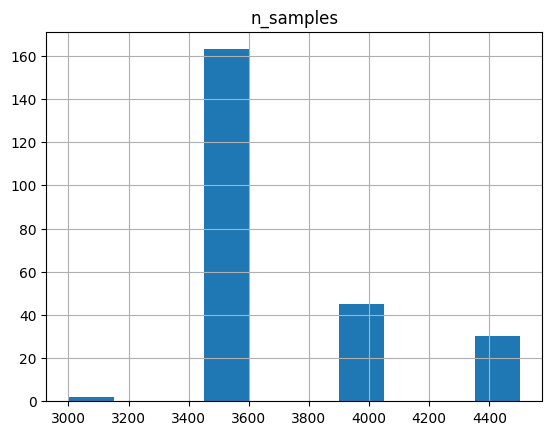

In [34]:
df_timeseries_metadata.hist(column="n_samples");

In [35]:
df_timeseries_metadata

,subject_id,movement_id,n_sensors,n_samples,n_dim
0,0,0,34,4001,3
1,0,1,34,4001,3
7,0,2,34,4001,3
8,0,3,34,4001,3
9,0,4,34,4001,3
...,...,...,...,...,...
92,15,10,34,4501,3
93,15,11,34,4501,3
94,15,12,34,4501,3
95,15,13,34,4501,3


In [36]:
round(df_timeseries_metadata["n_samples"].mean())

3716

# Number of multivariate signals, hours of recording

In [37]:
# number of multivariate signals
n_signals = n_subjects * n_movements_subject * n_sensors
print(f"{n_signals = }")

n_signals = 8160


## Number of hours of recording

In [38]:
sampling_frequency = 100 # Hz
total_nsamples = np.sum(df_timeseries_metadata["n_samples"])
total_seconds = round(total_nsamples // sampling_frequency)
print(total_seconds)

8918


In [39]:
print(round(seconds2hours(total_seconds), 1))

2.5


In [40]:
print(convert(total_seconds))

2:28:38


# Metadata: generated `json` files

In [41]:
path_json_files = Path("../Data_Smartarm_MC/MetaData/")
json_files = list(path_json_files.rglob("*.json"))
print(len(json_files))

240


# Metadata: cleaned `csv` files

## Movements annotations

In [42]:
df_movements_annotations = pd.read_csv("data/movements_annotations.csv")
df_movements_annotations.head()

,subject_ID,movement_ID,s1,e1,s2,e2,s3,e3
0,0,0,211,1357,1502,2892,2912.0,NaN
1,0,1,121,1357,1435,2634,2791.0,3990.0
2,0,2,113,1353,1534,2763,2930.0,NaN
3,0,3,246,1592,1697,3160,3275.0,NaN
4,0,4,313,1186,1303,3076,3255.0,NaN


In [43]:
print(df_movements_annotations["subject_ID"].nunique())  # number of subjects
print(len(df_movements_annotations))  # number of combination of subjects and movements

16
240


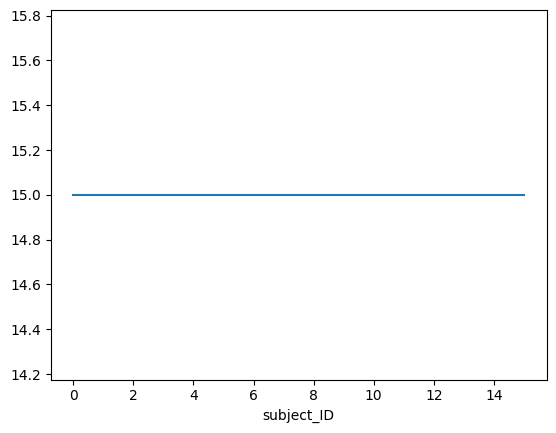

In [44]:
# all subjects have the same number of movements
df_movements_annotations.groupby(by=["subject_ID"])["movement_ID"].count().plot();

In [45]:
# all subjects do the same movements
l_movements = list()
unique_movements = list(df_movements_annotations["movement_ID"].unique())
for subject_ID in df_movements_annotations.subject_ID.unique():
    movements_subject = df_movements_annotations.query(f"subject_ID == {subject_ID}")["movement_ID"].tolist()
    l_movements.append(movements_subject)
    if set(movements_subject) != set(unique_movements):
        print(subject_ID)

In [46]:
n_movements_subject = len(set(movements_subject))  # number of movements for a single subject
print(n_movements_subject)

15


## Subjects

In [47]:
df_subjects_characteristics = pd.read_csv("data/subjects_characteristics.csv")
df_subjects_characteristics.head()

,subject_ID,gender,age,height_cm,weight_kg,BMI,laterality
0,0,M,30,175,77.0,25.1,NaN
1,1,M,28,179,73.0,22.8,L
2,2,M,27,188,78.0,22.1,R
3,3,F,50,172,68.0,23.0,R
4,4,F,52,156,64.0,26.3,NaN


In [48]:
df_subjects_characteristics["gender"].value_counts()

gender
M    11
F     5
Name: count, dtype: int64

In [49]:
df_subjects_characteristics["laterality"].value_counts()

laterality
R    7
L    1
Name: count, dtype: int64

In [50]:
df_subjects_characteristics["laterality"].isna().sum()

8

In [51]:
n_unique_subjects = df_subjects_characteristics["subject_ID"].nunique()
print(n_unique_subjects)
print(df_subjects_characteristics["subject_ID"].min())
print(df_subjects_characteristics["subject_ID"].max())

16
0
15


In [52]:
df_subjects_characteristics.describe().round(1).loc[["mean", "std", "min", "max"]].drop(columns=["subject_ID"])

,age,height_cm,weight_kg,BMI
mean,44.2,173.7,73.7,24.4
std,14.1,8.4,11.8,3.1
min,23.0,156.0,51.0,19.1
max,65.0,188.0,95.0,29.0


# Time series plot

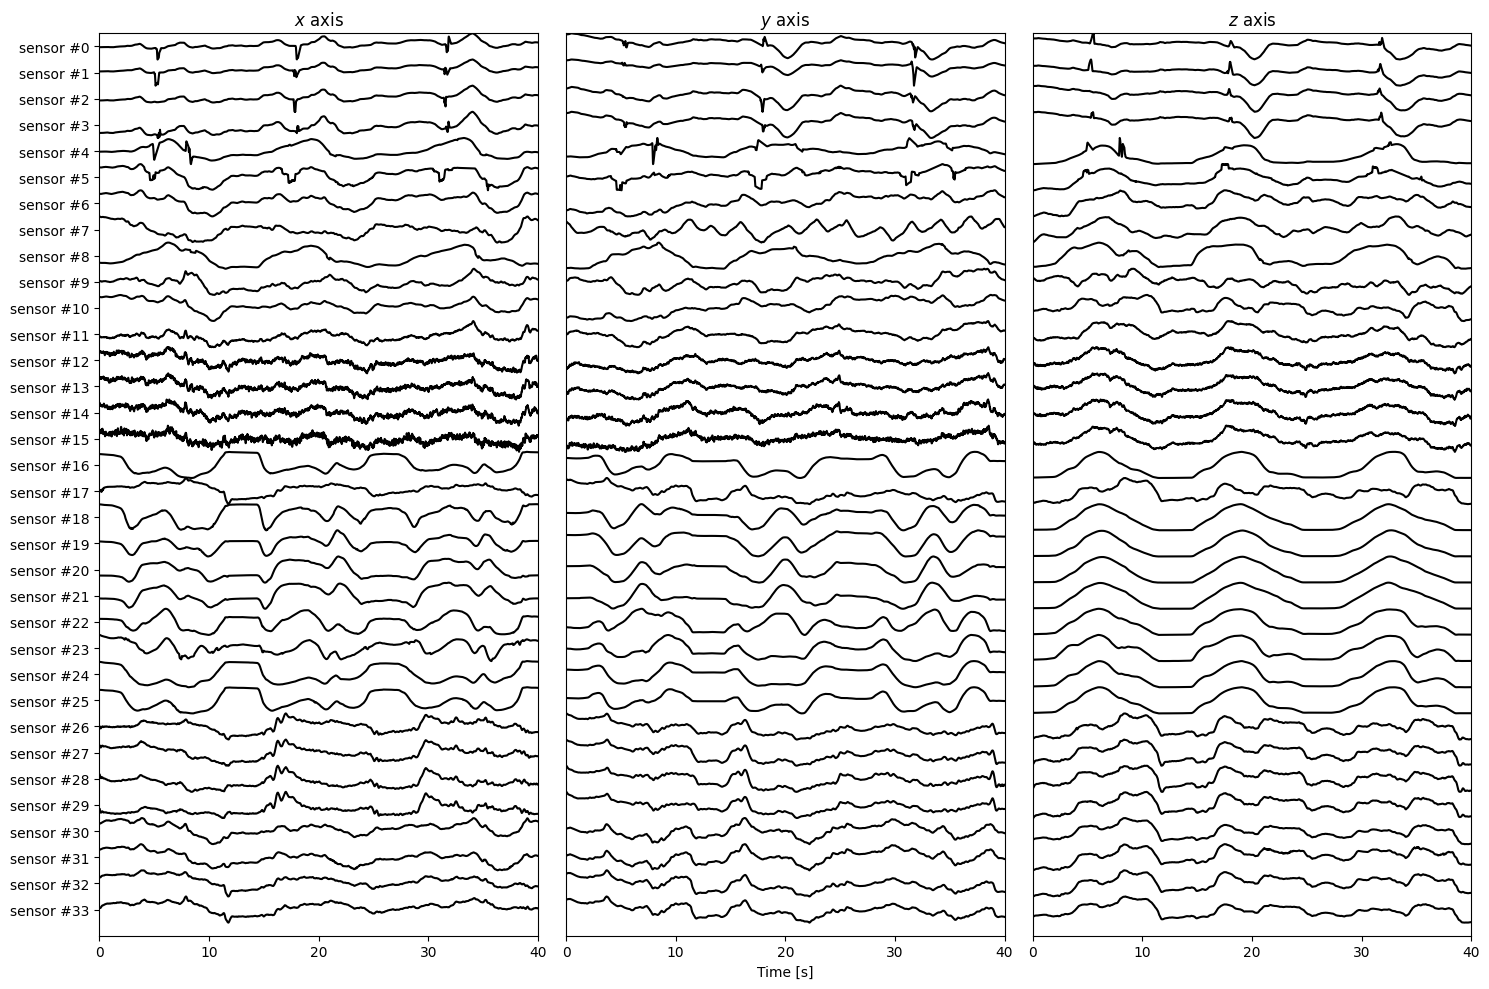

In [56]:
#ts = np.load('../Data_Smartarm_MC/smartarm_gapfree/smartarm_05_AMOD.npy')
ts = np.load('../Data_Smartarm_MC/smartarm_gapfree/armcoda_subject1_movement5.npy')

plt.figure(figsize=(15, 10))
names_tick = []
for i in range(len(ts)):
    names_tick.append('sensor #{}'.format(i))
    for j in range(3):
        plt.subplot(1,3,j+1)
        norm_ts = (ts[i][:,j]-min(ts[i][:,j]))/(max(ts[i][:,j])-min(ts[i][:,j]))
        plt.plot(norm_ts-(i+1.5),color='black')
plt.subplot(1,3,1)
plt.xlim(0,len(ts[0]))
plt.ylim(-len(ts)-1,-0.5)
plt.yticks(list(range(-len(ts),0))[::-1],names_tick)    
plt.xticks([0,1000, 2000, 3000, 4000],['0','10','20','30','40'])
plt.title('$x$ axis')
#plt.tight_layout()

plt.subplot(1,3,2)
plt.xlim(0,len(ts[0]))
plt.ylim(-len(ts)-1,-0.5)
plt.yticks([],[])
plt.xticks([0,1000, 2000, 3000, 4000],['0','10','20','30','40'])
plt.xlabel('Time [s]')
plt.title('$y$ axis')

plt.subplot(1,3,3)
plt.xlim(0,len(ts[0]))
plt.ylim(-len(ts)-1,-0.5)
plt.yticks([],[])
plt.xticks([0,1000, 2000, 3000, 4000],['0','10','20','30','40'])
plt.title('$z$ axis')
plt.tight_layout()
plt.margins(x=0)
plt.savefig("img/timeseries.png", dpi=200)
plt.show()